# Preprocessing external dataset: Kaufmann et al. (2021)

In [ ]:
import os
import pandas as pd
import numpy as np
import anndata as ad
import muon as mu
import scanpy as sc
from sklearn_ann.kneighbors.annoy import AnnoyTransformer
from scipy import sparse
from scipy.io import mmread

np.random.seed(42)

Source data downloaded from GEO (accession GSE144744)

# Load and preprocess data

Load raw counts and metadata for RNA and ADT modalities

In [2]:
counts_rna = mmread("../data/processed/external/kaufmann/source/RNA_counts/matrix.mtx").transpose().tocsc().astype("float64")
counts_adt = mmread("../data/processed/external/kaufmann/source/ADT_counts/matrix.mtx").transpose().tocsc().astype("float64")
barcodes_rna = pd.read_csv("../data/processed/external/kaufmann/source/RNA_counts/barcodes.tsv", sep="\t", header=None, index_col=0, names=[None])
var_rna = pd.read_csv("../data/processed/external/kaufmann/source/RNA_counts/genes.tsv", sep="\t", header=None, index_col=0, names=[None, "gene_symbol"])
barcodes_adt = pd.read_csv("../data/processed/external/kaufmann/source/ADT_counts/barcodes.tsv", sep="\t", header=None, index_col=0, names=[None])
var_adt = pd.read_csv("../data/processed/external/kaufmann/source/ADT_counts/genes.tsv", sep="\t", header=None, index_col=0, names=[None, "gene_symbol"])
obs = pd.read_csv("../data/processed/external/kaufmann/source/metadata_per_cell.csv", sep=",", header=0, index_col="cell_names")
obs.index.name = None
obs["HASH"] = obs["HASH"].fillna(obs["sample_10X"]) # fill missing values for unhashed samples
obs_rna = obs.loc[barcodes_rna.index].copy()
obs_adt = obs.loc[barcodes_adt.index].copy()

Construct AnnData objects for RNA and ADT data

In [3]:
adata_rna = ad.AnnData(X=counts_rna, obs=obs_rna, var=var_rna)
adata_adt = ad.AnnData(X=counts_adt, obs=obs_adt, var=var_adt)

Standardise gene names across datasets and aggregate counts for alias genes in original count matrix

In [4]:
translation = pd.read_csv("../data/processed/external/kaufmann/source/kaufmann_genes_translation.tsv", sep="\t", header=0, index_col="original_gene_symbol")
translation.index.name = None

adata_rna = adata_rna[:, translation.index].copy()
adata_rna.var = translation.copy()

grouped = translation.groupby('ensembl_id')
n_original_genes = adata_rna.n_vars
unique_ensembl_ids = translation['ensembl_id'].unique()
n_unique_genes = len(unique_ensembl_ids)
ensembl_to_new_idx = {ensembl_id: i for i, ensembl_id in enumerate(unique_ensembl_ids)}

row_indices = []
col_indices = []
data = []

for old_idx, (ensembl_id, gene_symbol) in enumerate(zip(translation['ensembl_id'], translation['gene_symbol'])):
    new_idx = ensembl_to_new_idx[ensembl_id]
    row_indices.append(new_idx)
    col_indices.append(old_idx)
    data.append(1.0)

aggregation_matrix = sparse.csr_matrix(
    (data, (row_indices, col_indices)), 
    shape=(n_unique_genes, n_original_genes)
)

X_aggregated = (aggregation_matrix @ adata_rna.X.T).T

new_var = pd.DataFrame(index=unique_ensembl_ids)
new_var['ensembl_id'] = unique_ensembl_ids
new_var['gene_symbol'] = [grouped.get_group(ensembl_id)['gene_symbol'].iloc[0] 
                          for ensembl_id in unique_ensembl_ids]
new_var['gene_type'] = [grouped.get_group(ensembl_id)['gene_type'].iloc[0]
                        for ensembl_id in unique_ensembl_ids]
new_var.index = new_var['gene_symbol']
new_var.index.name = None

adata_rna = ad.AnnData(
    X=X_aggregated,
    obs=adata_rna.obs.copy(),
    var=new_var
)
adata_rna.var_names_make_unique()

sc.pp.filter_genes(adata_rna, min_cells=1)

In [5]:
# Store raw counts for use with starCAT
adata_rna.raw = adata_rna
adata_adt.raw = adata_adt

# Normalise, find variable features across datasets and integrate

Load cell cycle genes (plain text files with one gene symbol per line containing the genes from Seurat `cc.genes$g2m.genes` and `cc.genes$s.genes`)

In [ ]:
with open("../data/ref/genes/g2m_genes.txt") as f:
    g2m_genes = f.read().splitlines()
    g2m_genes = [gene for gene in g2m_genes if gene in adata.var_names]

with open("../data/ref/genes/s_genes.txt") as f:
    s_genes = f.read().splitlines()
    s_genes = [gene for gene in s_genes if gene in adata.var_names]

Process RNA modality

In [7]:
sc.pp.normalize_total(adata_rna, target_sum=1e4)
sc.pp.log1p(adata_rna)
sc.tl.score_genes_cell_cycle(adata_rna, s_genes=s_genes, g2m_genes=g2m_genes)
sc.pp.highly_variable_genes(adata_rna, n_top_genes=5000, batch_key="HASH")
# Exclude mitochondrial and ribosomal genes from highly variable features
mito_genes = adata_rna.var_names.str.startswith("MT-")
ribo_genes = adata_rna.var_names.str.startswith(("RPS", "RPL"))
exclude_genes = mito_genes | ribo_genes
adata_rna.var.loc[exclude_genes, "highly_variable"] = False
adata_rna = adata_rna[:, adata_rna.var.highly_variable].copy()
sc.pp.regress_out(adata_rna, keys=["percent_mito", "S_score", "G2M_score"], n_jobs=16)
sc.pp.scale(adata_rna, max_value=10)
sc.pp.pca(adata_rna, n_comps=50, svd_solver="arpack")
sc.external.pp.harmony_integrate(adata_rna, key=["donor", "HASH", "V_10X"], max_iter_harmony=50)

2025-10-07 20:48:13,105 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-07 20:48:35,667 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-07 20:48:37,432 - harmonypy - INFO - Iteration 1 of 50
2025-10-07 20:52:09,349 - harmonypy - INFO - Iteration 2 of 50
2025-10-07 20:55:36,717 - harmonypy - INFO - Iteration 3 of 50
2025-10-07 20:59:03,327 - harmonypy - INFO - Iteration 4 of 50
2025-10-07 21:01:45,148 - harmonypy - INFO - Iteration 5 of 50
2025-10-07 21:04:42,004 - harmonypy - INFO - Iteration 6 of 50
2025-10-07 21:06:11,015 - harmonypy - INFO - Converged after 6 iterations


In [8]:
sc.pp.neighbors(adata_rna, transformer=AnnoyTransformer(n_neighbors=30, metric="angular"), use_rep="X_pca_harmony")
sc.tl.umap(adata_rna)

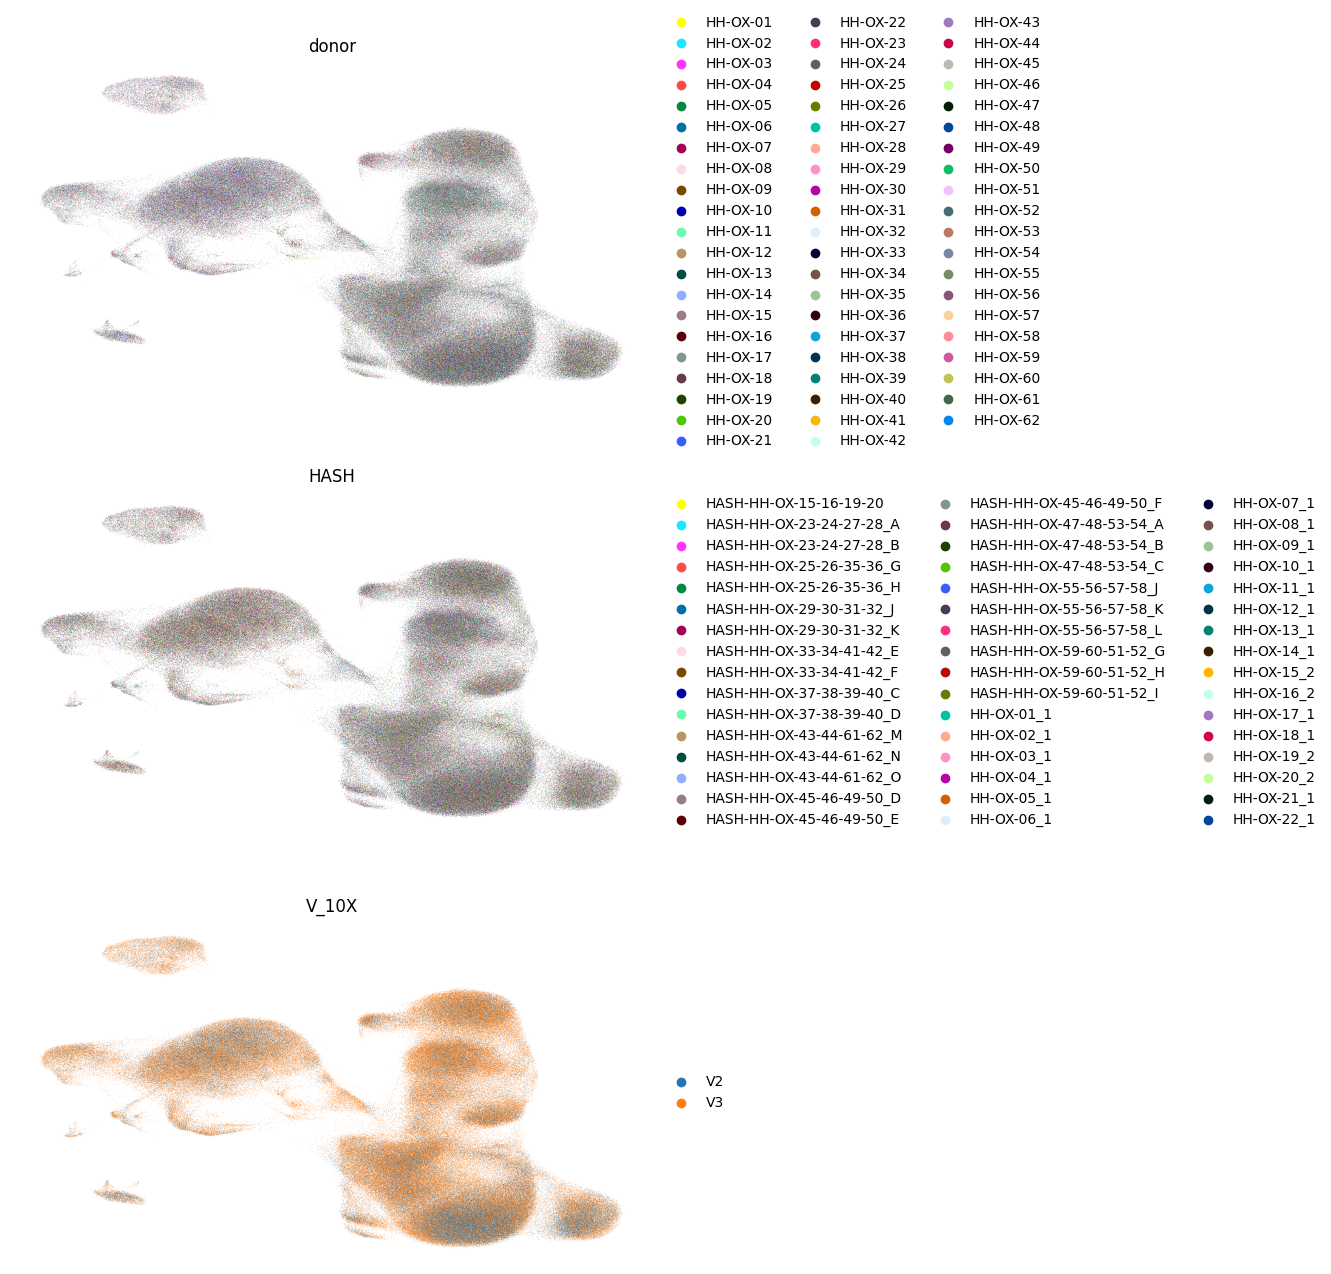

In [9]:
sc.pl.umap(adata_rna, color=["donor", "HASH", "V_10X"], wspace=0.4, frameon=False, ncols=1)

Process ADT modality

In [10]:
def seurat_clr_sample(adata, sample_key, axis=0, inplace=True):
    """
    Perform sample-wise Seurat-style CLR normalization on an AnnData object.

    Parameters
    ----------
    adata : AnnData
        AnnData object to normalize.
    sample_key : str
        Column in adata.obs indicating sample identity.
    axis : int, optional (default=0)
        Axis for CLR normalization (0 for features, 1 for cells).
    inplace : bool, optional (default=True)
        Whether to modify adata in place.

    Returns
    -------
    AnnData or None
        If inplace=False, returns a new AnnData object with batchwise CLR normalization.
        If inplace=True, modifies adata.X in place and returns None.
    """
    import warnings
    import numpy as np
    import scipy.sparse
    import scanpy as sc

    def seurat_clr(matrix, axis=0):
        # Store input characteristics
        is_sparse = scipy.sparse.issparse(matrix)
        orig_dtype = matrix.dtype
        if is_sparse:
            orig_format = matrix.getformat()
            mat = matrix.astype(float)
        else:
            mat = matrix.astype(float)

        # Prepare output
        out = np.zeros_like(mat, dtype=float) if not is_sparse else scipy.sparse.lil_matrix(mat.shape, dtype=float)

        if axis == 0:
            # per feature (columns)
            for j in range(mat.shape[1]):
                if is_sparse:
                    col = mat[:, j].toarray().ravel()
                else:
                    col = mat[:, j]
                nonzero = col > 0
                if np.any(nonzero):
                    g = np.exp(np.sum(np.log1p(col[nonzero])) / len(col))
                    clr_vals = np.log1p(col / g)
                else:
                    clr_vals = np.zeros_like(col)
                if is_sparse:
                    out[:, j] = clr_vals[:, None]
                else:
                    out[:, j] = clr_vals
        elif axis == 1:
            # per cell (rows)
            for i in range(mat.shape[0]):
                if is_sparse:
                    row = mat[i, :].toarray().ravel()
                else:
                    row = mat[i, :]
                nonzero = row > 0
                if np.any(nonzero):
                    g = np.exp(np.sum(np.log1p(row[nonzero])) / len(row))
                    clr_vals = np.log1p(row / g)
                else:
                    clr_vals = np.zeros_like(row)
                if is_sparse:
                    out[i, :] = clr_vals
                else:
                    out[i, :] = clr_vals
        else:
            raise ValueError("axis must be 0 (per feature) or 1 (per cell)")

        # Convert back to original type
        if is_sparse:
            out = out.asformat(orig_format)
        else:
            out = out.astype(orig_dtype)

        return out

    if adata.is_view:
        warnings.warn("Input AnnData is a view. Making a copy to avoid unexpected behavior.")
        adata = adata.copy()
    if sample_key not in adata.obs.columns:
        raise ValueError(f"sample_key '{sample_key}' not found in adata.obs columns.")
    if adata.X is None:
        raise ValueError("AnnData.X is None. Cannot perform CLR normalization.")
    
    samples = adata.obs[sample_key].unique()
    normalized_samples = []
    for sample in samples:
        adata_sample = adata[adata.obs[sample_key] == sample].copy()
        adata_sample.X = seurat_clr(adata_sample.X, axis=axis)
        normalized_samples.append(adata_sample)
    adata_clr = sc.concat(normalized_samples, axis=0, join="inner")
    adata_clr = adata_clr[adata.obs_names]  # reorder to match original

    if inplace:
        adata.X = adata_clr.X
    else:
        return adata_clr

In [11]:
seurat_clr_sample(adata_adt, sample_key="sample_10X", axis=0)
sc.pp.scale(adata_adt, max_value=10)
sc.pp.pca(adata_adt, n_comps=15, svd_solver="arpack")
sc.external.pp.harmony_integrate(adata_adt, key=["donor", "sample_10X", "HASH", "V_10X"], max_iter_harmony=50) # added sample_10X to batch variables to account for independent antibody stainings

2025-10-07 21:13:40,839 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-07 21:13:54,095 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-07 21:13:55,449 - harmonypy - INFO - Iteration 1 of 50
2025-10-07 21:17:10,808 - harmonypy - INFO - Iteration 2 of 50
2025-10-07 21:20:24,926 - harmonypy - INFO - Iteration 3 of 50
2025-10-07 21:23:38,426 - harmonypy - INFO - Iteration 4 of 50
2025-10-07 21:26:44,268 - harmonypy - INFO - Iteration 5 of 50
2025-10-07 21:28:51,966 - harmonypy - INFO - Iteration 6 of 50
2025-10-07 21:31:03,225 - harmonypy - INFO - Iteration 7 of 50
2025-10-07 21:33:13,616 - harmonypy - INFO - Iteration 8 of 50
2025-10-07 21:35:31,176 - harmonypy - INFO - Iteration 9 of 50
2025-10-07 21:37:32,256 - harmonypy - INFO - Converged after 9 iterations


In [12]:
sc.pp.neighbors(adata_adt, transformer=AnnoyTransformer(n_neighbors=30, metric="angular"), use_rep="X_pca_harmony")
sc.tl.umap(adata_adt)

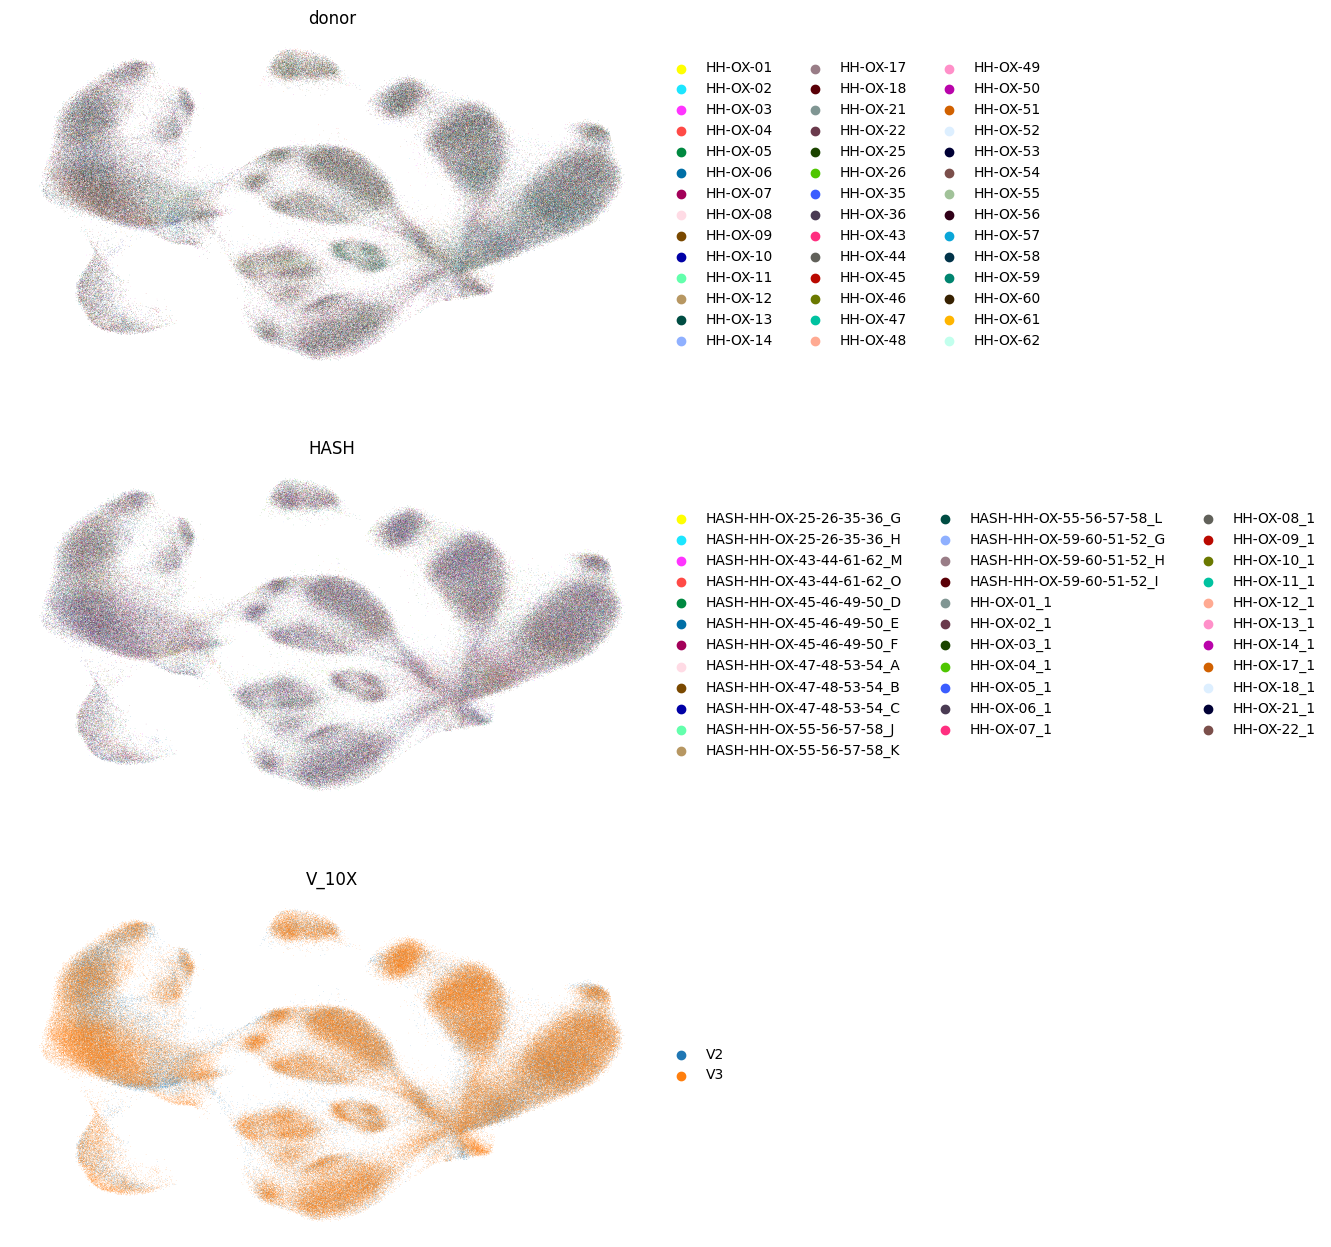

In [13]:
sc.pl.umap(adata_adt, color=["donor", "HASH", "V_10X"], wspace=0.4, frameon=False, ncols=1)

Build MuData object to store both processed modalities

In [14]:
mdata = mu.MuData({"RNA": adata_rna, "ADT": adata_adt})

/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [ ]:
# Save processed data
os.makedirs("../data/processed/external/kaufmann/annotated", exist_ok=True)
mdata.write_h5mu("../data/processed/external/kaufmann/annotated/kaufmann_full.h5mu")
mdata["RNA"].write_h5ad("../data/processed/external/kaufmann/annotated/kaufmann_full_rna.h5ad")
mdata["ADT"].write_h5ad("../data/processed/external/kaufmann/annotated/kaufmann_full_adt.h5ad")

/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
